# **1. Data preprocessing**

Dataset info

General Overview
The dataset comprises 7,043 individual customer records from a telecommunications company, providing a comprehensive snapshot of consumer behavior and service usage. Each instance represents a unique customer profile, characterized by 21 distinct features ranging from demographic information to service-specific metrics and billing details. The data serves as a benchmark for binary classification tasks, specifically focused on predicting Customer Churn—the phenomenon where clients terminate their service agreements with the provider.

Data Integrity and Synthetic Missingness While the original dataset from the provided source  is largely complete and consistent, it does not inherently contain a sufficient volume of missing values to conduct a robust comparative analysis of imputation techniques. To address the core research objective of this project—evaluating the impact of data recovery on model performance—a synthetic missingness of 10% has been manually injected into the features. This deliberate modification transforms the "clean" dataset into a challenging environment for data engineering.
Comparative Imputation Framework The primary motivation for introducing these gaps is to create a controlled experimental setup to compare four distinct data recovery strategies.

Dataset Link: https://www.kaggle.com/datasets/cdeotte/s6e3-original-dataset/data

In [ ]:
# wczytanie bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# wczytanie danych
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head(10))

In [ ]:
# usunięcie kolumny z ID klienta - jest ono zawsze unikalne, może przeszkadzać w klasyfikacji
df.drop('customerID', axis=1, inplace=True)
print(df.head(10))

In [ ]:
# wgląd w kolumny
print(df.describe())

In [ ]:
#sprawdzenie błędów
print("Wrong data per column:")
print((df == -200).sum())

In [ ]:
# sprawdzenie pustych rekordów
missing_data = df.isna().any().any()
print(f"Is missing data in the dataset: {missing_data}")
print(f"Missing data per column:")
print(df.isna().sum())

In [ ]:
# sprawdzenie zduplikowanych danych
print(f"Duplicated data:")
print(df.duplicated().sum())

Creating missing data

We are randomly creating missing data from dataset to compare imputation methods, even for column which depends on values from other colums - to point out how each method will deal with this problem.

In [ ]:
# sztuczne tworzenie braków w danych ze względu na ich kompletność - 10% danych

# ziarno losowości
np.random.seed(8)
# wybór kolumn do utworzenia braków, pomijamy kolumnę churn do klasyfikacji
# wybieramy także kolumny zależne od siebie, głównie po to, aby pokazać różnice pomiędzy metodami imputacji danych
cols_to_corrupt = [col for col in df.columns if col != 'Churn']

# 10% braków w każdej z kolumn
for col in cols_to_corrupt:
    # losowe 10% indeksów dla każdej z kolumn
    n_missing = int(len(df) * 0.1)
    missing_indices = np.random.choice(df.index, n_missing, replace=False)
    df.loc[missing_indices, col] = np.nan

# mapa braków danych
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa braków danych')
plt.show()

# podsumowanie procentowe i ilościowe brakujących rekordów dla wybranych kolumn
print("Procent braków w wybranych kolumnach:")
print(round((df.isnull().sum() / len(df) * 100), 2).head(10))
print("Weryfikacja braków po modyfikacji:")
print(df.isna().sum())
print(f"Braki w kolumnie Churn: {df['Churn'].isnull().sum()}")


In [ ]:
# ponowne sprawdzenie zduplikowanych danych
print(f"Duplicated data:")
print(df.duplicated().sum())

In [ ]:
# pobranie typów danych
df.info()

# enkodowanie nastąpi po imputacji danych, narazie niezbedne jest jedynie zmiana typu danych dla kolumny TotalChanges na numeryczne
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df[['TotalCharges']].dtypes)

The initial dataset was intentionally modified by introducing 10% missing values (NaN) across all features (excluding the target variable Churn). To address this, we implemented four distinct imputation strategies to evaluate their impact on model performance:
- Simple Statistical Imputation (Fills missing numerical values with the Median, categorical values with the Mode (the most frequent occurrence))
- Random Distributional Imputation (Fills missing values with random sample from existing, non-missing values)
- K-Nearest Neighbors (KNN) Imputation (Fills missing values with most similar records based on other features)
- Multivariate Iterative Imputation (MICE) (Fills missing values with strategy that treats each feature with missing values as a function of other features)

Each of these four methods will be further split into two scaling variants: Min-Max Scaling (Range 0-1) and Standardization (Mean 0, Std 1), resulting in 8 unique datasets for the classification stage.

Functions for our methods

In [ ]:
# funkcje do uzycia dla każdej metody

# funkcja do imputacji - funkcja do uniwersalnego przeprowadzenia imputacji dla dowolnej metody
def apply_imputation(df_dirty, imputer_object):
    # kopia datasetu
    df_temp = df_dirty.copy()

    imputed_data = imputer_object.fit_transform(df_temp)
    
    # wynik jako DataFrame
    df_imputed = pd.DataFrame(imputed_data, columns=df_temp.columns)
        
    print("✅ Missing values filled")

    return df_imputed

# funkcja do trasnformacji
def transform_data(df_input):
    df_t = df_input.copy()
    
    # mapowanie kolumn binarnych true/false, yes/no, male/female
    binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 'True': 1, 'False': 0}
    
    pure_binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
    
    for col in pure_binary_cols:
        if col in df_t.columns:
            df_t[col] = df_t[col].map(binary_map)
            
    # One-Hot Encoding dla wszystkich pozostałych kolumn kategorycznych, no internet service jako osobna cecha
    
    categorical_cols = [
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
        'Contract', 'PaymentMethod'
    ]
    
    # tworzenie kolumn binarnych z kategorycznych, ustawiamy je także na binarne wartości 1/0
    df_t = pd.get_dummies(df_t, columns=categorical_cols, dtype=int)
    
    print("✅ Data encoded")

    return df_t

# funkcja do matrycy korelacji
def plot_correlation(df_ready, method_name):
    plt.figure(figsize=(15, 10))
    # obliczanie korelacji
    corr = df_ready.corr()
    # mapa
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
    plt.title(f"Correlation Matrix - {method_name}")
    plt.show()

# funkcja do wykresu rozkładu
def plot_distribution(df_imputed, column_name, method_name):
    plt.figure(figsize=(8, 4))
    sns.histplot(df_imputed[column_name], kde=True, color='teal')
    plt.title(f"Distribution of {column_name} - {method_name}")
    plt.show()

# funkcja skalowania min-max (wariant A datasetów)
def manual_min_max(df_input):
    df_scaled = df_input.copy()
    # skalowanie wszystkiego oprócz kolumny Churn, klasyfikacji
    features = [col for col in df_scaled.columns if col != 'Churn']
    
    for col in features:
        c_min = df_scaled[col].min()
        c_max = df_scaled[col].max()
        if c_max - c_min != 0:
            df_scaled[col] = (df_scaled[col] - c_min) / (c_max - c_min)
            
    
    print("✅ Data scaled with min-max method")

    return df_scaled

# funkcja do standaryzacji (wariant B datasetów)
def manual_standardization(df_input):
    df_scaled = df_input.copy()
    features = [col for col in df_scaled.columns if col != 'Churn']
    
    for col in features:
        mu = df_scaled[col].mean()
        sigma = df_scaled[col].std()
        if sigma != 0:
            df_scaled[col] = (df_scaled[col] - mu) / sigma
            
    print("✅ Data scaled with manual standarization")
    
    return df_scaled

Simple Statistical Imputation

In [ ]:
# imputacja
from sklearn.impute import SimpleImputer

# kopia datasetu
df_copy = df.copy()

# za pomocą biblioteki sklearn i funkcji SimpleImputer definujemy strategię, którą chcemy wypełnić puste miejsca na dane
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# podzielenie danych
df_copy_num = df_copy.select_dtypes(include=[np.number])
df_copy_cat = df_copy.select_dtypes(include=['object'])
# imputacja danych
df_copy_num_fixed = apply_imputation(df_copy_num, num_imputer)
df_copy_cat_fixed = apply_imputation(df_copy_cat, cat_imputer)

# scalenie w całość
df_1_fixed = pd.concat([df_copy_num_fixed, df_copy_cat_fixed], axis=1)

# sprawdzenie
missing_data_1 = df_1_fixed.isna().any().any()
print(f"Is missing data in the dataset: {missing_data_1}")
print(f"Missing data per column:")
print(df_1_fixed.isna().sum())

In [ ]:
# transformacja
df_1 = transform_data(df_1_fixed)
df_1['SeniorCitizen'] = df_1['SeniorCitizen'].astype('int64')
df_1.info()
print(f"Number of colums after the transformation: {df_1.shape[1]}")

In [ ]:
# macierz korelacji
plot_correlation(df_1, "Simple Statistical Imputation - Method 1")

# wykres rozkładu
# kolumny wartościowe do analizy
cols_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in cols_to_analyze:
    plot_distribution(df_1, col, "Simple Statistical Imputation - Method 1")

In [ ]:
# warianty standaryzacji

# wariant A - min-max
df_1A = manual_min_max(df_1)
print(df_1A.head())
# wariant B - standaryzacja
df_1B = manual_standardization(df_1)
print(df_1B.head())

Random Distributional Imputation

In [ ]:
# imputacja

# kopia datasetu
df_copy = df.copy()

# losowanie wartości już występujących
for col in df_copy.columns:
    if df_copy[col].isnull().any():
        # pobieranie istniejących wartości, bez NaN
        valid_values = df_copy[col].dropna()
        # ile jest braków wartości
        num_nulls = df_copy[col].isnull().sum()
        # losowanie wartości
        random_samples = np.random.choice(valid_values, size=num_nulls, replace=True)
        # wstawienie wartości
        df_copy.loc[df_copy[col].isnull(), col] = random_samples

# imputacja danych
df_2_fixed = df_copy

# sprawdzenie
missing_data_2 = df_2_fixed.isna().any().any()
print(f"Is missing data in the dataset: {missing_data_2}")
print(f"Missing data per column:")
print(df_2_fixed.isna().sum())

In [ ]:
# transformacja
df_2 = transform_data(df_2_fixed)
df_2['SeniorCitizen'] = df_2['SeniorCitizen'].astype('int64')
df_2.info()
print(f"Number of colums after the transformation: {df_2.shape[1]}")

In [ ]:
# macierz korelacji
plot_correlation(df_2, "Random Distributional Imputation - Method 2")

# wykres rozkładu
# kolumny wartościowe do analizy
cols_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in cols_to_analyze:
    plot_distribution(df_2, col, "Random Distributional Imputation - Method 2")

In [ ]:
# warianty standaryzacji

# wariant A - min-max
df_2A = manual_min_max(df_2)
print(df_2A.head())
# wariant B - standaryzacja
df_2B = manual_standardization(df_2)
print(df_2B.head())

K-Nearest Neighbors (KNN) Imputation

In [ ]:
from sklearn.impute import KNNImputer

df_copy = df.copy()

# transformacja jako pierwsza w przypadku modelu, korzysta on z liczb 0/1
df_3 = transform_data(df_copy)
# definicja imputera, zgadywanie na podstawie 5 najbliższych sąsiadów
knn_imp = KNNImputer(n_neighbors=5)


In [ ]:
# imputacja danych
df_3 = apply_imputation(df_3, knn_imp)
df_3['SeniorCitizen'] = df_3['SeniorCitizen'].astype('int64')
df_3.info()
print(f"Number of colums after the transformation: {df_3.shape[1]}")

# sprawdzenie
missing_data_3 = df_3.isna().any().any()
print(f"Is missing data in the dataset: {missing_data_3}")
print(f"Missing data per column:")
print(df_3.isna().sum())

In [ ]:
# macierz korelacji
plot_correlation(df_3, "K-Nearest Neighbors Imputation - Method 3")

# wykres rozkładu
# kolumny wartościowe do analizy
cols_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in cols_to_analyze:
    plot_distribution(df_3, col, "K-Nearest Neighbors Imputation - Method 3")

In [ ]:
# warianty standaryzacji

# wariant A - min-max
df_3A = manual_min_max(df_3)
print(df_3A.head())
# wariant B - standaryzacja
df_3B = manual_standardization(df_3)
print(df_3B.head())

Multivariate Iterative Imputation (MICE)

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_copy = df.copy()

# transformacja jako pierwsza w przypadku modelu, korzysta on z liczb 0/1
df_4 = transform_data(df_copy)
# definicja imputera, model max 10 razy poprawi swoje przewidywania
iter_imp = IterativeImputer(max_iter=10, random_state=42)

In [115]:
# imputacja danych
df_4 = apply_imputation(df_4, iter_imp)
df_4['SeniorCitizen'] = df_4['SeniorCitizen'].astype('int64')
df_4.info()
print(f"Number of colums after the transformation: {df_4.shape[1]}")

# sprawdzenie
missing_data_4 = df_4.isna().any().any()
print(f"Is missing data in the dataset: {missing_data_4}")
print(f"Missing data per column:")
print(df_4.isna().sum())

✅ Missing values filled
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   float64
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   float64
 3   Dependents                               7043 non-null   float64
 4   tenure                                   7043 non-null   float64
 5   PhoneService                             7043 non-null   float64
 6   PaperlessBilling                         7043 non-null   float64
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7043 non-null   float64
 9   Churn                                    7043 non-null   float64
 10  MultipleLines_No                   

c:\Users\MIŁOSZ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


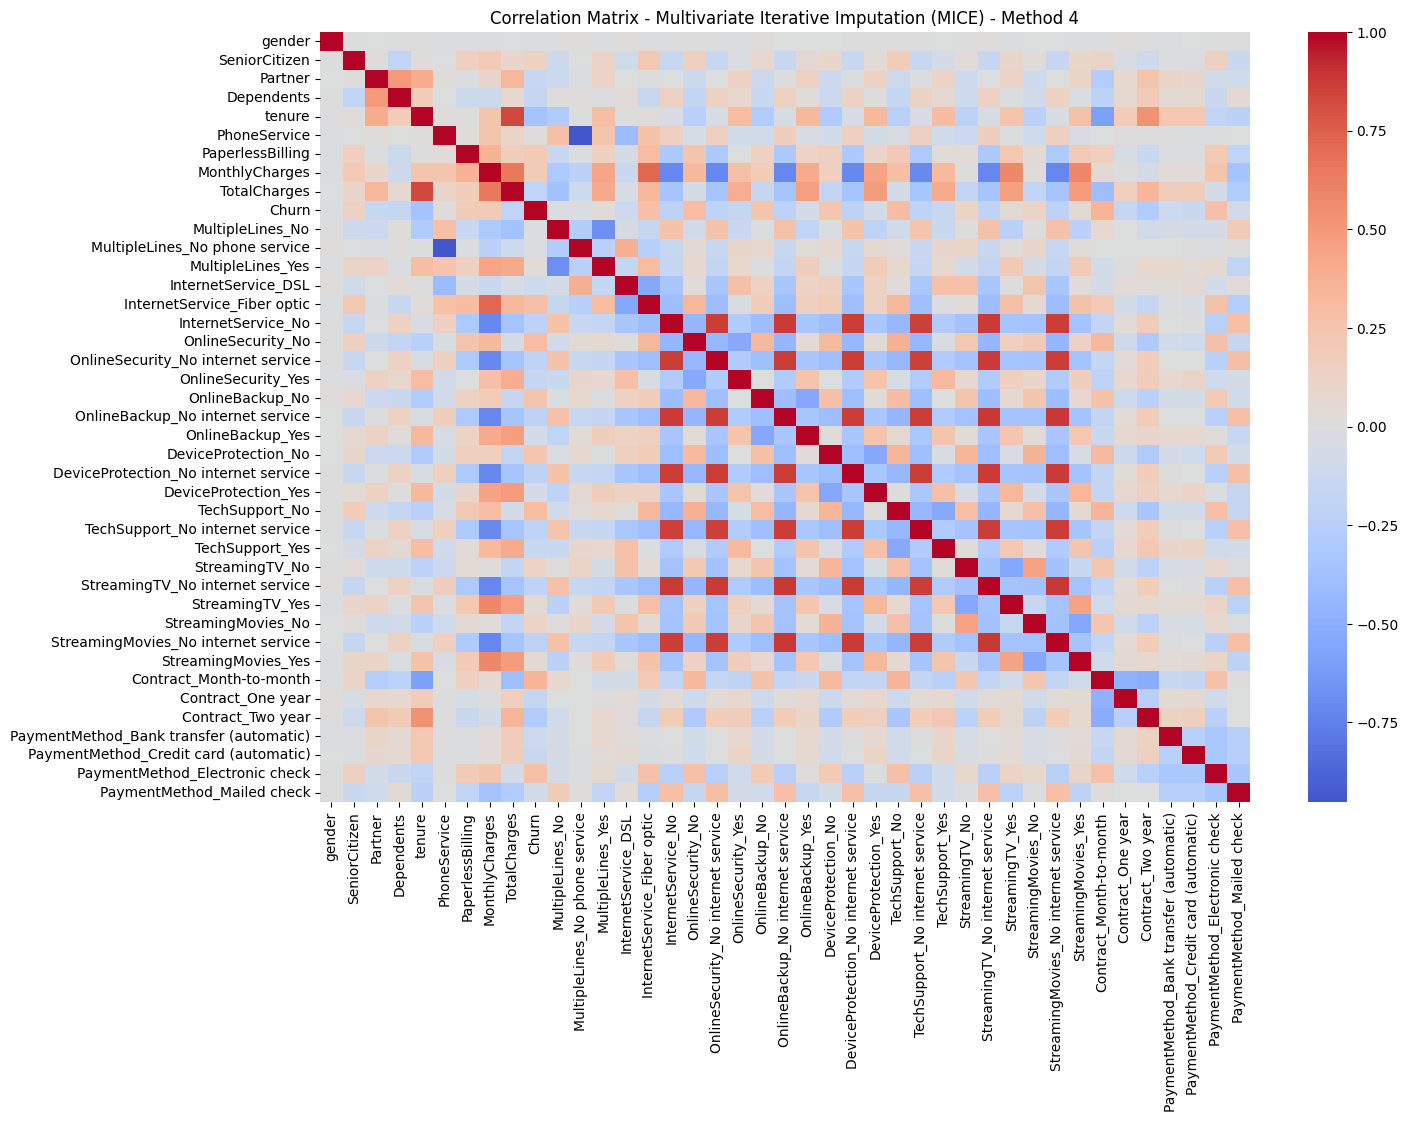

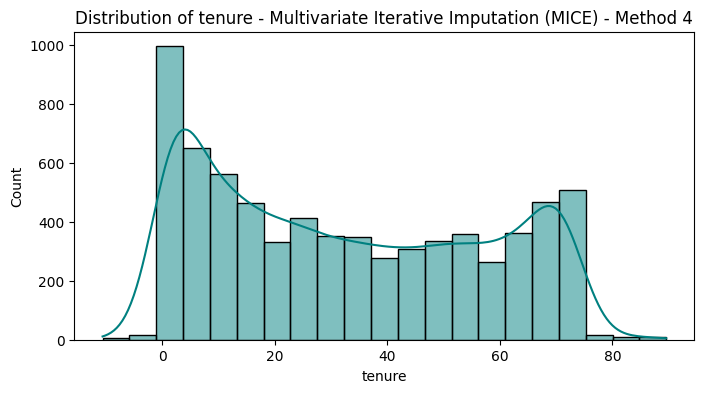

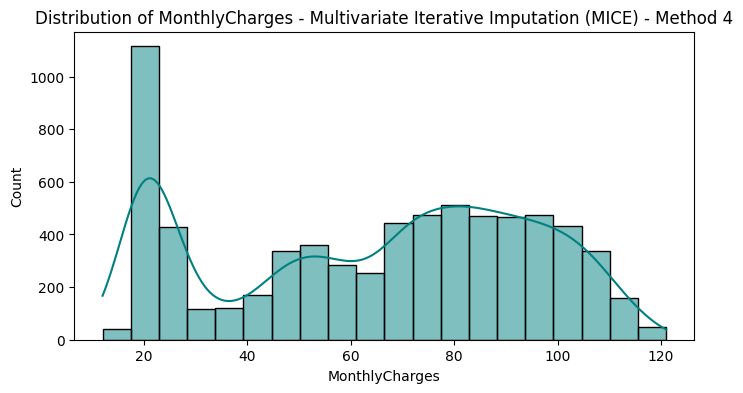

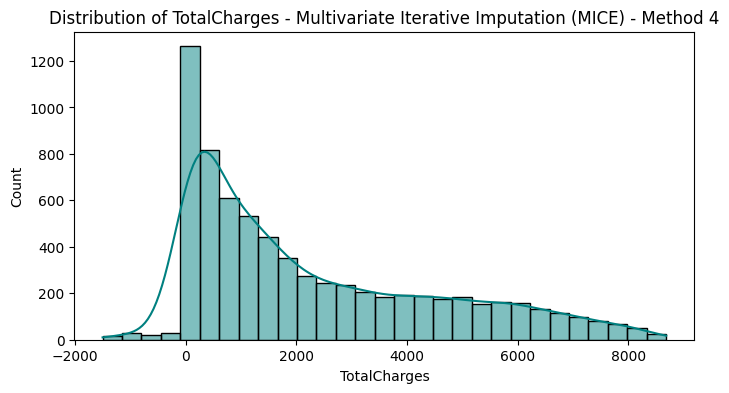

In [116]:
# macierz korelacji
plot_correlation(df_4, "Multivariate Iterative Imputation (MICE) - Method 4")

# wykres rozkładu
# kolumny wartościowe do analizy
cols_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in cols_to_analyze:
    plot_distribution(df_4, col, "Multivariate Iterative Imputation (MICE) - Method 4")

In [117]:
# warianty standaryzacji

# wariant A - min-max
df_4A = manual_min_max(df_4)
print(df_4A.head())
# wariant B - standaryzacja
df_4B = manual_standardization(df_4)
print(df_4B.head())

✅ Data scaled with min-max method
     gender  SeniorCitizen   Partner  Dependents    tenure  PhoneService  \
0  0.000000            0.0  0.797127    0.210936  0.115960      0.066795   
1  0.512286            0.0  0.000000    0.334007  0.445371      0.878975   
2  1.000000            0.0  0.000000    0.210936  0.125943      0.878975   
3  1.000000            0.0  0.000000    0.210936  0.555175      0.066795   
4  0.000000            0.0  0.000000    0.210936  0.125943      0.878975   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0          1.000000        0.163160      0.150528    0.0  ...   
1          0.000000        0.386958      0.333050    0.0  ...   
2          1.000000        0.383496      0.158213    1.0  ...   
3          0.424148        0.277459      0.328266    0.0  ...   
4          1.000000        0.538191      0.162483    1.0  ...   

   StreamingMovies_No  StreamingMovies_No internet service  \
0                 1.0                                  0

Consistency Validation Test

In [118]:
# definicja funkcji sprawdzającej błędy logiczne przy imputacji danych

def evaluate_imputation_quality(df_test, method_name):
    # rekordy bez internetu - kolumny od której zależą inne
    no_internet = (df_test['InternetService_No'] == 1)
    df_no_int = df_test[no_internet]
    
    # sprawdzane kolumny
    services_yes = [
        'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 
        'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes'
    ]
    
    services_no = [
        'OnlineSecurity_No', 'OnlineBackup_No', 'DeviceProtection_No', 
        'TechSupport_No', 'StreamingTV_No', 'StreamingMovies_No'
    ]
    
    total_customers_no_int = len(df_no_int)
    errors_yes = 0
    errors_no = 0

    if total_customers_no_int > 0:
        # wartość TAK pomimo braku internetu
        for col in services_yes:
            if col in df_no_int.columns:
                errors_yes += (df_no_int[col] == 1).sum()
        # wartość NIE pomimo braku internetu
        for col in services_no:
            if col in df_no_int.columns:
                errors_no += (df_no_int[col] == 1).sum()
    
    total_logical_errors = errors_yes + errors_no
    possible_slots = total_customers_no_int * (len(services_yes) + len(services_no))
    
    error_rate_total = (total_logical_errors / possible_slots) * 100 if possible_slots > 0 else 0

    # współczynniki błędu
    print(f"--- DETAILED Imputation quality: {method_name} ---")
    print(f"Clients without internet: {total_customers_no_int}")
    print(f"Errors in 'Yes' columns: {errors_yes}")
    print(f"Errors in 'No' columns: {errors_no}")
    print(f"Total logical inconsistencies: {total_logical_errors}")
    print(f"OVERALL Inconsistency Rate: {error_rate_total:.2f}%")
    print("-" * 50)
    
    return {
        'method': method_name,
        'errors_yes': errors_yes,
        'errors_no': errors_no,
        'total_errors': total_logical_errors,
        'rate': error_rate_total
    }

In [119]:
# porównanie dla każdej metody
m1_results = evaluate_imputation_quality(df_1, "Simple Statistical Imputation")
m2_results = evaluate_imputation_quality(df_2, "Random Distributional Imputation")
m3_results = evaluate_imputation_quality(df_3, "K-Nearest Neighbors (KNN) Imputation")
m4_results = evaluate_imputation_quality(df_4, "Multivariate Iterative Imputation (MICE)")

--- DETAILED Imputation quality: Simple Statistical Imputation ---
Clients without internet: 1365
Errors in 'Yes' columns: 0
Errors in 'No' columns: 857
Total logical inconsistencies: 857
OVERALL Inconsistency Rate: 5.23%
--------------------------------------------------
--- DETAILED Imputation quality: Random Distributional Imputation ---
Clients without internet: 1522
Errors in 'Yes' columns: 590
Errors in 'No' columns: 809
Total logical inconsistencies: 1399
OVERALL Inconsistency Rate: 7.66%
--------------------------------------------------
--- DETAILED Imputation quality: K-Nearest Neighbors (KNN) Imputation ---
Clients without internet: 1365
Errors in 'Yes' columns: 0
Errors in 'No' columns: 0
Total logical inconsistencies: 0
OVERALL Inconsistency Rate: 0.00%
--------------------------------------------------
--- DETAILED Imputation quality: Multivariate Iterative Imputation (MICE) ---
Clients without internet: 1365
Errors in 'Yes' columns: 0
Errors in 'No' columns: 0
Total logi